# Seleção de Jogos do Dataset Steam (HuggingFace)

Lê o `FronkonGames/steam-games-dataset`, filtra e estratifica jogos para o estudo NLP.
Saída: `data/raw/games.csv` — ~100 a 150 jogos com targets e metadados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

## 1. Carregar dataset

In [2]:
HF_URL = "hf://datasets/FronkonGames/steam-games-dataset/data/train-00000-of-00001.parquet"

print("Loading HF dataset...")
raw = pd.read_parquet(HF_URL)
print(f"Loaded: {len(raw):,} rows, {raw.shape[1]} columns")
raw.head(2)

Loading HF dataset...


Loaded: 124,146 rows, 41 columns


,appID,name,release_date,estimated_owners,peak_ccu,required_age,price,dlc_count,detailed_description,short_description,supported_languages,full_audio_languages,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,user_score,positive,negative,score_rank,achievements,recommendations,notes,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,developers,publishers,categories,genres,tags,screenshots,movies,packages
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,,,[],[],,https://shared.akamai.steamstatic.com/store_item_assets/...,,,,True,False,False,0,,0,0,0,,0,0,,0,0,0,0,[],[],[],[],[],[https://shared.akamai.steamstatic.com/store_item_assets...,[],[]
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,0,"Springtime, April: when the cherry trees come into full ...","Spring has come, and our protagonist, Yukinari, returns ...",[English],[],,https://shared.akamai.steamstatic.com/store_item_assets/...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,,0,252,3,,0,231,,8,0,8,0,[minori],[MangaGamer],"[Single-player, Steam Trading Cards, Steam Cloud, Family...",[Adventure],[],[https://shared.akamai.steamstatic.com/store_item_assets...,[],"[{""title"": ""Buy Supipara - Chapter 1 Spring Has Come!"", ..."


In [3]:
# Show available columns
print(raw.dtypes.to_string())

appID                           str
name                            str
release_date                    str
estimated_owners                str
peak_ccu                      int64
required_age                  int64
price                       float64
dlc_count                     int64
detailed_description            str
short_description               str
supported_languages          object
full_audio_languages         object
reviews                         str
header_image                    str
website                         str
support_url                     str
support_email                   str
windows                        bool
mac                            bool
linux                          bool
metacritic_score              int64
metacritic_url                  str
user_score                    int64
positive                      int64
negative                      int64
score_rank                      str
achievements                  int64
recommendations             

## 2. Limpeza e parsing

In [4]:
df = raw.copy()

# Parse release_date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Numeric coercion
for col in ['positive', 'negative', 'price', 'metacritic_score', 'user_score']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Parse estimated_owners: midpoint of range e.g. '20000 - 50000'
def parse_owners(s):
    if pd.isna(s) or s == '0 - 0':
        return np.nan
    parts = str(s).replace(',', '').split(' - ')
    try:
        vals = [int(p.strip()) for p in parts if p.strip().isdigit()]
        return np.mean(vals) if vals else np.nan
    except:
        return np.nan

df['owners_mid'] = df['estimated_owners'].apply(parse_owners)

print(f"release_date parsed: {df['release_date'].notna().sum():,} non-null")
print(f"owners_mid: {df['owners_mid'].notna().sum():,} non-null")

release_date parsed: 124,146 non-null
owners_mid: 101,113 non-null


## 3. Aplicar filtros base

In [5]:
MIN_REVIEWS = 200
YEAR_MIN    = 2020  # 2020+ for better Reddit/YouTube data coverage
YEAR_MAX    = 2024

NON_GAME_GENRES = {
    'Video Production', 'Audio Production', 'Photo Editing',
    'Animation & Modeling', 'Utilities', 'Web Publishing', 'Education',
}

def has_non_game_genre(genres_val) -> bool:
    try:
        if genres_val is None:
            return False
        items = set(genres_val) if hasattr(genres_val, '__iter__') and not isinstance(genres_val, str) \
                else set(str(genres_val).replace("'", "").strip("[]").split())
        return bool(NON_GAME_GENRES & items)
    except Exception:
        return False

f = df[
    df['release_date'].notna() &
    (df['release_date'].dt.year >= YEAR_MIN) &
    (df['release_date'].dt.year <= YEAR_MAX) &
    ((df['positive'].fillna(0) + df['negative'].fillna(0)) >= MIN_REVIEWS) &
    (~df['genres'].apply(has_non_game_genre))
].copy()

print(f"After base filters: {len(f):,} games (from {len(df):,})")
print(f"Period: {YEAR_MIN}â€“{YEAR_MAX}, min reviews: {MIN_REVIEWS}, non-game genres excluded")

After base filters: 6,974 games (from 124,146)
Period: 2020â€“2024, min reviews: 200, non-game genres excluded


In [6]:
# Compute rating_ratio
f['total_reviews'] = f['positive'] + f['negative']
f['rating_ratio']  = f['positive'] / f['total_reviews']

# Studio tier proxy: based on owners_mid
def tier(owners):
    if pd.isna(owners):          return 'unknown'
    if owners >= 2_000_000:      return 'AAA'
    if owners >= 200_000:        return 'AA'
    return 'indie'

f['tier'] = f['owners_mid'].apply(tier)

print(f['tier'].value_counts())
print()
print(f"rating_ratio stats:\n{f['rating_ratio'].describe().round(3)}")

tier
indie    5321
AA       1487
AAA       166
Name: count, dtype: int64

rating_ratio stats:
count    6974.000
mean        0.829
std         0.127
min         0.103
25%         0.763
50%         0.858
75%         0.926
max         1.000
Name: rating_ratio, dtype: float64


## 4. Identificar sucessos e fracassos claros

In [7]:
# Clear success: rating_ratio >= 0.80 ("Very Positive" / "Overwhelmingly Positive")
# Clear flop:   rating_ratio <= 0.50 ("Mixed" or worse)
# Middle ground excluded â€” reduces noise in binary classification

SUCCESS_THRESH = 0.80
FLOP_THRESH    = 0.50

success = f[f['rating_ratio'] >= SUCCESS_THRESH].copy()
flop    = f[f['rating_ratio'] <= FLOP_THRESH].copy()

print(f"Clear successes (â‰¥{SUCCESS_THRESH}): {len(success):,}")
print(f"Clear flops    (â‰¤{FLOP_THRESH}): {len(flop):,}")

Clear successes (â‰¥0.8): 4,621
Clear flops    (â‰¤0.5): 171


## 5. Amostragem estratificada

In [8]:
N_SUCCESS = 75  # target count per class
N_FLOP    = 75
SEED      = 42

def stratified_sample(pool, n, seed):
    tiers = ['AAA', 'AA', 'indie', 'unknown']
    weights = {'AAA': 0.15, 'AA': 0.25, 'indie': 0.55, 'unknown': 0.05}
    parts = []
    for t in tiers:
        sub = pool[pool['tier'] == t]
        k = max(1, int(n * weights.get(t, 0.05)))
        k = min(k, len(sub))
        if k > 0:
            parts.append(sub.nlargest(k * 3, 'total_reviews').sample(k, random_state=seed))
    sampled = pd.concat(parts).drop_duplicates(subset='appID')
    remaining = pool[~pool['appID'].isin(sampled['appID'])]
    deficit = n - len(sampled)
    if deficit > 0 and len(remaining) > 0:
        extra = remaining.nlargest(deficit * 2, 'total_reviews').sample(
            min(deficit, len(remaining)), random_state=seed
        )
        sampled = pd.concat([sampled, extra])
    return sampled.head(n)

s_success = stratified_sample(success, N_SUCCESS, SEED)
s_flop    = stratified_sample(flop,    N_FLOP,    SEED)

print(f"Sampled successes: {len(s_success)} | tier breakdown:\n{s_success['tier'].value_counts()}")
print()
print(f"Sampled flops:     {len(s_flop)} | tier breakdown:\n{s_flop['tier'].value_counts()}")

Sampled successes: 75 | tier breakdown:
tier
indie    41
AA       18
AAA      16
Name: count, dtype: int64



Sampled flops:     75 | tier breakdown:
tier
indie    46
AA       24
AAA       5
Name: count, dtype: int64


In [9]:
games = pd.concat([s_success, s_flop]).drop_duplicates(subset='appID').copy()
games['label_rating'] = (games['rating_ratio'] >= SUCCESS_THRESH).astype(int)

# Sales label: F2P excluded (price == 0); threshold = median owners_mid of paid games.
# Rationale: median is the natural split of the empirical distribution.
# Resulting imbalance (~70/30) is handled in the ML pipeline via class_weight='balanced'
# in LogisticRegression and StratifiedKFold; SMOTE is available as fallback.
games_paid = games[games['price'].fillna(0) > 0].copy()
sales_thresh = games_paid['owners_mid'].median()
games_paid['label_sales'] = (games_paid['owners_mid'] >= sales_thresh).astype(int)

print(f"Total games: {len(games)}")
print(f"  label_rating=1: {games['label_rating'].sum()} | =0: {(games['label_rating']==0).sum()}")
print(f"  paid games: {len(games_paid)}")
print(f"  label_sales=1: {games_paid['label_sales'].sum()} | =0: {(games_paid['label_sales']==0).sum()}")
print(f"  sales threshold (median owners_mid): {sales_thresh:,.0f}")

Total games: 150
  label_rating=1: 75 | =0: 75
  paid games: 138
  label_sales=1: 93 | =0: 45
  sales threshold (median owners_mid): 150,000


## 6. EDA — gráficos de distribuição

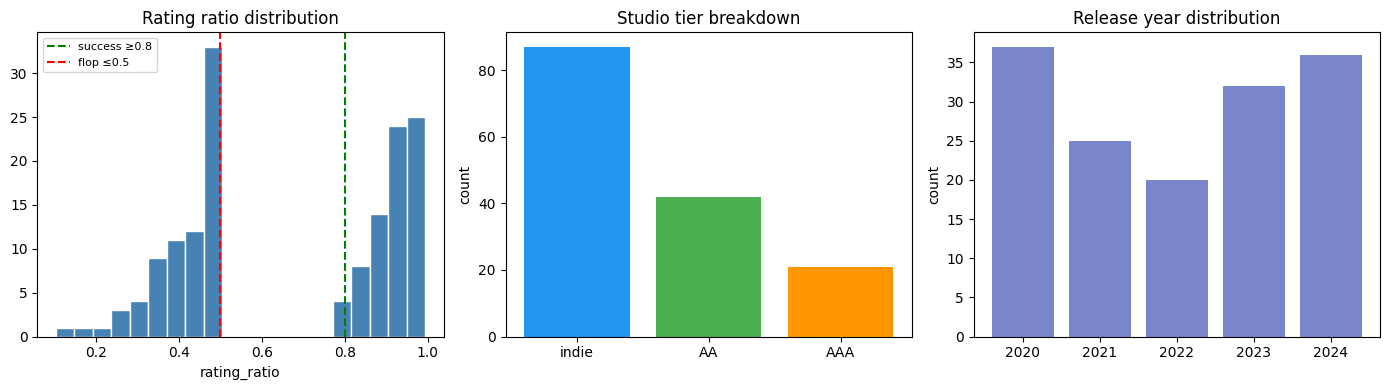

Saved: reports/figures/01_game_selection_eda.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Rating ratio distribution
axes[0].hist(games['rating_ratio'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(SUCCESS_THRESH, color='green', linestyle='--', label=f'success â‰¥{SUCCESS_THRESH}')
axes[0].axvline(FLOP_THRESH,    color='red',   linestyle='--', label=f'flop â‰¤{FLOP_THRESH}')
axes[0].set_xlabel('rating_ratio')
axes[0].set_title('Rating ratio distribution')
axes[0].legend(fontsize=8)

# Tier breakdown
tier_counts = games['tier'].value_counts()
axes[1].bar(tier_counts.index, tier_counts.values, color=['#2196F3','#4CAF50','#FF9800','#9E9E9E'])
axes[1].set_title('Studio tier breakdown')
axes[1].set_ylabel('count')

# Release year
games['release_year'] = games['release_date'].dt.year
year_counts = games['release_year'].value_counts().sort_index()
axes[2].bar(year_counts.index, year_counts.values, color='#7986CB')
axes[2].set_title('Release year distribution')
axes[2].set_ylabel('count')

plt.tight_layout()
plt.savefig('../reports/figures/01_game_selection_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/figures/01_game_selection_eda.png")

## 7. Exportar games.csv

In [11]:
KEEP_COLS = [
    'appID', 'name', 'release_date', 'developers', 'publishers',
    'genres', 'tags', 'positive', 'negative', 'total_reviews',
    'rating_ratio', 'estimated_owners', 'owners_mid', 'price',
    'metacritic_score', 'user_score', 'tier', 'label_rating', 'release_year'
]

keep = [c for c in KEEP_COLS if c in games.columns]
out  = games[keep].sort_values('rating_ratio', ascending=False).reset_index(drop=True)

out.to_csv('../data/raw/games.csv', index=False)
print(f"Saved: data/raw/games.csv ({len(out)} games, {len(keep)} columns)")
out[['appID', 'name', 'release_date', 'tier', 'rating_ratio', 'estimated_owners', 'label_rating']].head(20)

Saved: data/raw/games.csv (150 games, 19 columns)


,appID,name,release_date,tier,rating_ratio,estimated_owners,label_rating
0,2070550,A Castle Full of Cats,2022-11-09,indie,0.994263,100000 - 200000,1
1,1260520,Patrick's Parabox,2022-03-29,indie,0.992174,100000 - 200000,1
2,1567800,æ˜Ÿç©ºåˆ—è½¦ä¸Žç™½çš„æ—…è¡Œ,2021-05-14,indie,0.987620,20000 - 50000,1
3,1794680,Vampire Survivors,2022-10-20,AAA,0.984601,5000000 - 10000000,1
4,1145360,Hades,2020-09-17,AAA,0.982441,5000000 - 10000000,1
5,1434480,Maitetsu:Last Run!!,2020-10-30,indie,0.982035,100000 - 200000,1
6,1669980,Volcano Princess,2023-04-20,AA,0.978388,1000000 - 2000000,1
7,1765350,å€™é¸Ÿ,2023-01-11,indie,0.977847,20000 - 50000,1
8,1229490,ULTRAKILL,2020-09-03,AAA,0.977119,5000000 - 10000000,1
9,1202540,Marco & The Galaxy Dragon,2020-02-28,indie,0.975099,50000 - 100000,1


In [12]:
print("=" * 60)
print("GAME SELECTION SUMMARY")
print("=" * 60)
print(f"Total games selected : {len(out)}")
print(f"  Successes (label=1): {out['label_rating'].sum()}")
print(f"  Flops     (label=0): {(out['label_rating']==0).sum()}")
print(f"Period               : {out['release_year'].min()} â€“ {out['release_year'].max()}")
print(f"Tier breakdown       : {dict(out['tier'].value_counts())}")
print(f"Avg rating_ratio     : {out['rating_ratio'].mean():.3f}")
print(f"rating_ratio range   : [{out['rating_ratio'].min():.3f}, {out['rating_ratio'].max():.3f}]")
print()
print("Top 5 successes:")
print(out.nlargest(5, 'rating_ratio')[['name', 'tier', 'rating_ratio', 'estimated_owners']].to_string(index=False))
print()
print("Top 5 flops:")
print(out.nsmallest(5, 'rating_ratio')[['name', 'tier', 'rating_ratio', 'estimated_owners']].to_string(index=False))

GAME SELECTION SUMMARY
Total games selected : 150
  Successes (label=1): 75
  Flops     (label=0): 75
Period               : 2020 â€“ 2024
Tier breakdown       : {'indie': np.int64(87), 'AA': np.int64(42), 'AAA': np.int64(21)}
Avg rating_ratio     : 0.666
rating_ratio range   : [0.103, 0.994]

Top 5 successes:
                 name  tier  rating_ratio   estimated_owners
A Castle Full of Cats indie      0.994263    100000 - 200000
    Patrick's Parabox indie      0.992174    100000 - 200000
            æ˜Ÿç©ºåˆ—è½¦ä¸Žç™½çš„æ—…è¡Œ indie      0.987620      20000 - 50000
    Vampire Survivors   AAA      0.984601 5000000 - 10000000
                Hades   AAA      0.982441 5000000 - 10000000

Top 5 flops:
                             name  tier  rating_ratio estimated_owners
                     SuperPower 3 indie      0.102607   50000 - 100000
                         Bhop PRO indie      0.182573        0 - 20000
Call of DutyÂ®: Modern WarfareÂ® II indie      0.234612        0 - 20000
    